<a href="https://colab.research.google.com/github/Vanngoccc/DeepLearning/blob/main/RNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Bài học về Mạng nơ-ron hồi quy (RNN) để dự đoán chuỗi thời gian

Bài notebook này minh họa cách sử dụng Mạng nơ-ron hồi quy (Recurrent Neural Network - RNN) đơn giản để dự đoán chuỗi thời gian. Chúng ta sẽ trải qua các bước từ chuẩn bị dữ liệu, xây dựng mô hình, huấn luyện và đánh giá hiệu suất.

In [1]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(42)
np.random.seed(42)

### 1. Chuẩn bị dữ liệu chuỗi thời gian

Trong phần này, chúng ta sẽ tạo một chuỗi thời gian giả lập dựa trên hàm sin với một chút nhiễu ngẫu nhiên (`0.1 * np.random.randn`). Điều này giúp mô phỏng dữ liệu thực tế có biến động.

- **Chuẩn hóa dữ liệu (Min-Max Scaling)**:
  `data = (data - data_min) / (data_max - data_min)`
  Bước này rất quan trọng. Chúng ta chuẩn hóa dữ liệu về khoảng `[0, 1]`. Việc này giúp mô hình học ổn định và hiệu quả hơn, đặc biệt là khi sử dụng các hàm kích hoạt (activation functions) như sigmoid hoặc tanh trong mạng nơ-ron, vì chúng hoạt động tốt nhất với dữ liệu nằm trong một phạm vi nhỏ.
  `data = torch.FloatTensor(data).unsqueeze(1)`: Chuyển đổi mảng NumPy thành Tensor của PyTorch và thêm một chiều (unsqueeze) để phù hợp với định dạng đầu vào của RNN (thường là `(số_lượng_mẫu, chiều_dài_chuỗi, số_lượng_đặc_trưng)`).

- **Tạo chuỗi (Sequences)**:
  Hàm `create_sequences` được sử dụng để chuyển đổi chuỗi thời gian liên tục thành các cặp `(chuỗi_đầu_vào, giá_trị_dự_đoán)`. Với `seq_length = 10`, mỗi `X` sẽ là một chuỗi 10 giá trị liên tiếp và `y` sẽ là giá trị tiếp theo ngay sau chuỗi đó. Đây là cách phổ biến để chuẩn bị dữ liệu cho các bài toán dự đoán chuỗi thời gian với RNN.

- **Chia tập Train/Test**:
  Dữ liệu được chia thành 80% cho huấn luyện (`train_size = int(0.8 * len(X))`) và 20% còn lại cho kiểm tra. Điều quan trọng là phải giữ nguyên thứ tự thời gian khi chia tập, tức là dữ liệu huấn luyện luôn ở trước dữ liệu kiểm tra để tránh rò rỉ thông tin từ tương lai.

- **Trực quan hóa dữ liệu**: Biểu đồ hiển thị chuỗi sin đã chuẩn hóa và ranh giới giữa tập huấn luyện và tập kiểm tra, giúp chúng ta hình dung cấu trúc dữ liệu.

X shape: torch.Size([190, 10, 1])  y shape: torch.Size([190, 1])
Train: 152, Test: 38


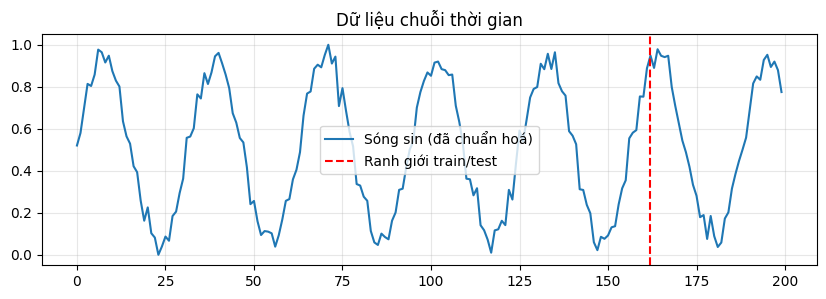

In [2]:
time_steps = 200
x = np.linspace(0, 40, time_steps)
data = np.sin(x) + 0.1 * np.random.randn(time_steps)

# Chuẩn hoá min-max về [0, 1] để output sigmoid hoặc tanh dễ học hơn.
data_min, data_max = data.min(), data.max()
data = (data - data_min) / (data_max - data_min)
data = torch.FloatTensor(data).unsqueeze(1)   # shape (200, 1)

def create_sequences(series, seq_length):
    X, y = [], []
    for i in range(len(series) - seq_length):
        X.append(series[i : i + seq_length])
        y.append(series[i + seq_length])
    return torch.stack(X), torch.stack(y)

seq_length = 10
X, y = create_sequences(data, seq_length)
print('X shape:', X.shape, ' y shape:', y.shape)   # (190, 10, 1) và (190, 1)

# Chia 80/20.
train_size = int(0.8 * len(X))
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]
print(f'Train: {len(X_train)}, Test: {len(X_test)}')

# Vẽ chuỗi gốc để có cảm giác về dữ liệu.
plt.figure(figsize=(10, 3))
plt.plot(data.numpy(), label='Sóng sin (đã chuẩn hoá)')
plt.axvline(train_size + seq_length, color='red', linestyle='--', label='Ranh giới train/test')
plt.legend(); plt.grid(alpha=0.3); plt.title('Dữ liệu chuỗi thời gian')
plt.show()

### 2. Định nghĩa Mô hình RNN

Chúng ta xây dựng một mô hình RNN đơn giản bằng PyTorch kế thừa từ `nn.Module`.

- **`__init__(self, input_size=1, hidden_size=20, output_size=1)`**:
  - `input_size=1`: Mỗi bước thời gian trong chuỗi đầu vào của chúng ta chỉ có 1 đặc trưng (là giá trị của sóng sin tại thời điểm đó).
  - `hidden_size=20`: Đây là kích thước của `hidden state` (trạng thái ẩn) của RNN. Trạng thái ẩn là 'bộ nhớ' của RNN, nó mang thông tin từ các bước thời gian trước đó. Giá trị này quyết định khả năng mô hình nắm bắt được các phụ thuộc dài hạn trong chuỗi. Kích thước lớn hơn có thể giúp mô hình học được các pattern phức tạp hơn nhưng cũng dễ dẫn đến quá khớp (overfitting) và tốn tài nguyên hơn.
  - `output_size=1`: Chúng ta muốn dự đoán một giá trị số duy nhất ở bước thời gian tiếp theo.
  - `self.rnn = nn.RNN(input_size, hidden_size, batch_first=True)`: Khởi tạo lớp RNN của PyTorch. `batch_first=True` nghĩa là dữ liệu đầu vào có định dạng `(batch_size, seq_length, input_size)`. Nếu là `False`, định dạng sẽ là `(seq_length, batch_size, input_size)`.
  - `self.fc = nn.Linear(hidden_size, output_size)`: Một lớp tuyến tính (fully connected layer) nhận đầu vào là `hidden_size` (từ trạng thái ẩn cuối cùng của RNN) và xuất ra `output_size` (giá trị dự đoán).

- **`forward(self, x)`**:
  Đây là hàm định nghĩa cách dữ liệu chảy qua mạng.
  - `out, _ = self.rnn(x)`: Dữ liệu đầu vào `x` (có shape `(batch, seq_len, input_size)`) được đưa vào lớp RNN. Lớp RNN sẽ tính toán `output` cho mỗi bước thời gian và trạng thái ẩn cuối cùng (mà chúng ta không dùng trực tiếp ở đây, nên dùng `_`). `out` có shape `(batch, seq_len, hidden_size)`. Nó chứa trạng thái ẩn tại *mỗi* bước thời gian.
  - `out = self.fc(out[:, -1, :])`: Vì chúng ta chỉ quan tâm đến việc dự đoán giá trị tiếp theo sau *toàn bộ* chuỗi đầu vào, chúng ta chỉ lấy trạng thái ẩn của *bước thời gian cuối cùng* trong chuỗi. `out[:, -1, :]` chọn tất cả các mẫu trong batch (`:`), trạng thái ẩn của bước cuối cùng (`-1`), và tất cả các chiều của trạng thái ẩn (`:`). Output của lớp tuyến tính `fc` sẽ có shape `(batch, output_size)`.

In [3]:
class RNN(nn.Module):
    def __init__(self, input_size=1, hidden_size=20, output_size=1):
        super().__init__()
        self.hidden_size = hidden_size
        self.rnn = nn.RNN(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        # PyTorch tự khởi tạo h0 = 0 nếu mình không truyền vào.
        out, _ = self.rnn(x)             # out shape: (batch, seq_len, hidden_size)
        out = self.fc(out[:, -1, :])     # chỉ lấy bước cuối cùng → (batch, output_size)
        return out

model = RNN()
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-2)
print(model)

RNN(
  (rnn): RNN(1, 20, batch_first=True)
  (fc): Linear(in_features=20, out_features=1, bias=True)
)


### 3. Huấn luyện Mô hình

Phần này thiết lập và thực hiện quá trình huấn luyện cho mô hình RNN của chúng ta.

- **`train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=16, shuffle=True)`**:
  - `TensorDataset(X_train, y_train)`: Kết hợp dữ liệu đầu vào `X_train` và nhãn `y_train` thành một dataset.
  - `DataLoader`: Tạo ra một iterator để duyệt qua dataset theo từng `batch_size` (ở đây là 16). Việc huấn luyện theo batch giúp quá trình cập nhật trọng số ổn định hơn và hiệu quả hơn về mặt tính toán so với huấn luyện từng mẫu một. `shuffle=True` xáo trộn dữ liệu trong mỗi epoch để mô hình không học theo thứ tự cố định của các mẫu.

- **`num_epochs = 100`**: Số lượng vòng lặp mà mô hình sẽ duyệt qua toàn bộ dữ liệu huấn luyện.
- **`loss_history = []`**: Danh sách để lưu lại giá trị loss trung bình sau mỗi epoch, giúp chúng ta theo dõi quá trình hội tụ của mô hình.

- **Vòng lặp huấn luyện chính (`for epoch in range(num_epochs):`)**:
  - **`model.train()`**: Đặt mô hình vào chế độ huấn luyện. Điều này kích hoạt các lớp như Dropout (nếu có) và BatchNorm (nếu có), chúng có hành vi khác nhau giữa huấn luyện và đánh giá.
  - **`optimizer.zero_grad()`**: Đây là bước cực kỳ quan trọng. Trước khi tính toán gradient cho batch hiện tại, chúng ta cần *reset* các gradient từ batch trước về 0. Nếu không, các gradient sẽ bị tích lũy, dẫn đến cập nhật trọng số không chính xác.
  - **`output = model(X_batch)`**: Thực hiện forward pass: đưa batch dữ liệu đầu vào `X_batch` qua mô hình để nhận về dự đoán.
  - **`loss = criterion(output, y_batch)`**: Tính toán giá trị mất mát giữa dự đoán của mô hình (`output`) và giá trị thực (`y_batch`) bằng hàm `MSELoss`.
  - **`loss.backward()`**: Thực hiện backward pass (lan truyền ngược). Bước này tính toán gradient của hàm mất mát đối với tất cả các trọng số trong mô hình. Các gradient được lưu trữ trong thuộc tính `.grad` của mỗi tham số.
  - **`optimizer.step()`**: Cập nhật trọng số của mô hình dựa trên các gradient đã được tính toán ở bước `loss.backward()` và thuật toán tối ưu hóa (`Adam`).
  - **Theo dõi và in `avg_loss`**: Tính toán mất mát trung bình cho mỗi epoch và in ra sau mỗi 10 epoch để theo dõi tiến độ huấn luyện.

In [4]:

train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=16, shuffle=True)

num_epochs = 100
loss_history = []

for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0.0
    n_samples = 0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        output = model(X_batch)
        loss = criterion(output, y_batch)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item() * X_batch.size(0)
        n_samples += X_batch.size(0)

    avg_loss = epoch_loss / n_samples
    loss_history.append(avg_loss)

    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch+1:3d}/{num_epochs}] loss = {avg_loss:.5f}')

Epoch [ 10/100] loss = 0.00300
Epoch [ 20/100] loss = 0.00271
Epoch [ 30/100] loss = 0.00258
Epoch [ 40/100] loss = 0.00329
Epoch [ 50/100] loss = 0.00299
Epoch [ 60/100] loss = 0.00275
Epoch [ 70/100] loss = 0.00305
Epoch [ 80/100] loss = 0.00259
Epoch [ 90/100] loss = 0.00256
Epoch [100/100] loss = 0.00276


### 4. Đánh giá Mô hình

Sau khi huấn luyện, chúng ta đánh giá hiệu suất của mô hình trên tập dữ liệu kiểm tra (`X_test`, `y_test`). Có hai cách đánh giá chính:

1.  **Dự đoán một bước (One-step-ahead prediction)**:
    - **Cách hoạt động**: Mô hình dự đoán giá trị tiếp theo dựa trên *chuỗi đầu vào thực tế* (`X_test`). Ví dụ, để dự đoán `y[t]`, mô hình nhận `X[t-seq_length : t-1]` từ dữ liệu *thực tế*. Điều này có nghĩa là mỗi dự đoán là độc lập và luôn dựa trên thông tin chính xác từ quá khứ gần.
    - **Độ chính xác**: Phương pháp này thường cho kết quả tốt nhất vì nó luôn có thông tin đầu vào đáng tin cậy.
    - **Ứng dụng**: Phù hợp cho các tình huống cần dự đoán giá trị tiếp theo một cách chính xác dựa trên dữ liệu hiện có (ví dụ: dự đoán giá cổ phiếu cho ngày mai).

2.  **Dự đoán tự hồi quy (Rollout / Auto-regressive prediction)**:
    - **Cách hoạt động**: Mô hình dự đoán giá trị tiếp theo, sau đó *chính dự đoán đó* được đưa trở lại làm một phần của chuỗi đầu vào cho bước dự đoán tiếp theo. Ví dụ, để dự đoán `y[t]`, mô hình nhận `X[t-seq_length : t-1]`. Sau khi dự đoán `y[t]`, để dự đoán `y[t+1]`, mô hình sẽ nhận `[X[t-seq_length+1 : t-1], y[t] (dự đoán)]`.
    - **Độ chính xác**: Phương pháp này có xu hướng tích lũy lỗi. Một lỗi nhỏ ở bước dự đoán hiện tại có thể gây ra sai lệch lớn hơn ở các bước dự đoán tiếp theo, vì mô hình 'tự tham chiếu' vào các dự đoán không hoàn hảo của chính nó.
    - **Ứng dụng**: Phù hợp để mô phỏng hành vi của chuỗi thời gian trong tương lai dài hạn hoặc để kiểm tra độ mạnh mẽ của mô hình trước các lỗi nhỏ (ví dụ: dự báo thời tiết dài hạn, mô phỏng quá trình động học).

- **`model.eval()`**: Đặt mô hình vào chế độ đánh giá. Điều này vô hiệu hóa các lớp có hành vi khác nhau giữa huấn luyện và đánh giá (như Dropout, BatchNorm) để đảm bảo kết quả nhất quán.
- **`with torch.no_grad()`**: Vô hiệu hóa việc tính toán và lưu trữ gradient. Điều này giúp tiết kiệm bộ nhớ và tăng tốc độ tính toán vì chúng ta không cần cập nhật trọng số trong quá trình đánh giá.

- **Baseline (Naive prediction)**:
  `naive_pred = X_test[:, -1, 0].numpy()`: Đây là một mô hình rất đơn giản, dự đoán rằng giá trị tiếp theo sẽ bằng giá trị cuối cùng được thấy trong chuỗi đầu vào. `MSE` của mô hình ngây thơ này (`mse_naive`) được dùng làm điểm tham chiếu. Mô hình RNN của chúng ta phải đạt `MSE` thấp hơn đáng kể so với `mse_naive` thì mới được coi là có hiệu quả.

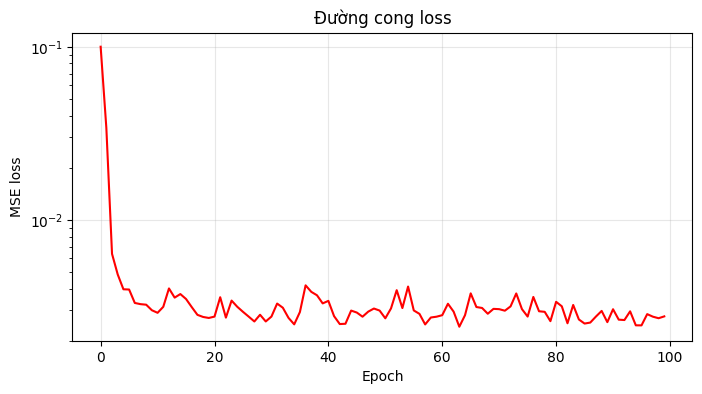

In [5]:

plt.figure(figsize=(8, 4))
plt.plot(loss_history, color='red')
plt.xlabel('Epoch'); plt.ylabel('MSE loss'); plt.title('Đường cong loss')
plt.grid(alpha=0.3); plt.yscale('log')
plt.show()

In [6]:
model.eval()
with torch.no_grad():
    pred_one_step = model(X_test).squeeze().numpy()
    truth        = y_test.squeeze().numpy()

mse = np.mean((pred_one_step - truth) ** 2)
mae = np.mean(np.abs(pred_one_step - truth))
print(f'One-step MSE = {mse:.5f},  MAE = {mae:.5f}')

# Baseline ngây thơ: "giá trị tiếp theo bằng giá trị cuối cùng đã thấy".
naive_pred = X_test[:, -1, 0].numpy()
mse_naive = np.mean((naive_pred - truth) ** 2)
print(f'Baseline (naive) MSE = {mse_naive:.5f}  ← RNN phải đánh bại con số này mới gọi là học được gì.')

One-step MSE = 0.00235,  MAE = 0.04097
Baseline (naive) MSE = 0.00600  ← RNN phải đánh bại con số này mới gọi là học được gì.


### 5. So sánh các kiểu dự đoán

Phần này trực quan hóa và so sánh kết quả của hai phương pháp dự đoán (one-step và rollout) với giá trị thực tế trên tập kiểm tra. Bạn sẽ thấy rằng dự đoán one-step thường gần với giá trị thực tế hơn, trong khi dự đoán rollout có thể sai lệch đáng kể khi thời gian dự đoán càng kéo dài do lỗi tích lũy.

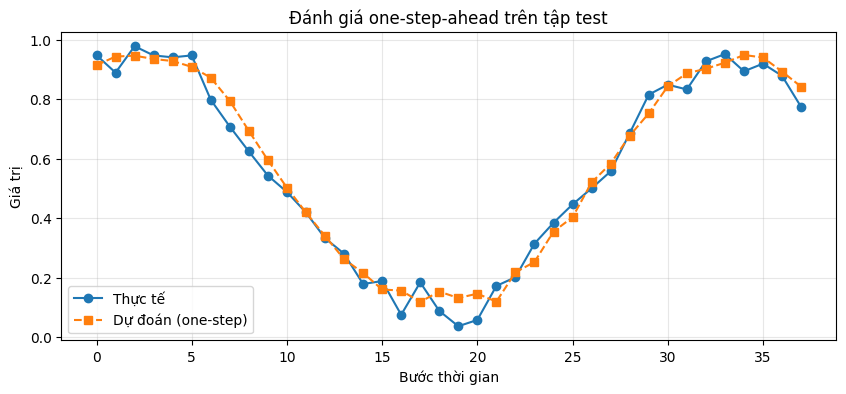

In [7]:
plt.figure(figsize=(10, 4))
plt.plot(truth, 'o-', label='Thực tế')
plt.plot(pred_one_step, 's--', label='Dự đoán (one-step)')
plt.title('Đánh giá one-step-ahead trên tập test')
plt.xlabel('Bước thời gian'); plt.ylabel('Giá trị')
plt.legend(); plt.grid(alpha=0.3)
plt.show()

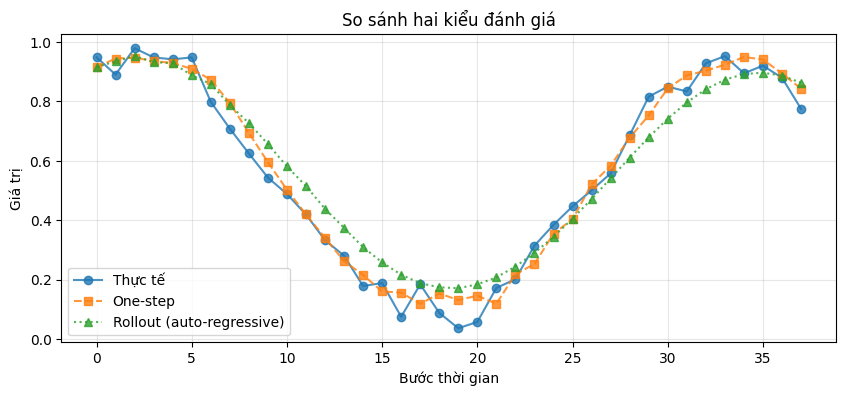

One-step MSE: 0.00235
Rollout  MSE: 0.00604  ← lớn hơn nhiều, đúng như dự đoán.


In [8]:
model.eval()
rollout = []
with torch.no_grad():
    inputs = X_test[0].unsqueeze(0).clone()   # shape (1, 10, 1)
    for _ in range(len(X_test)):
        out = model(inputs)                   # (1, 1)
        rollout.append(out.item())
        # Đẩy out vào cuối, bỏ phần tử đầu — cửa sổ trượt 1 bước.
        next_step = out.unsqueeze(0)          # (1, 1, 1)
        inputs = torch.cat([inputs[:, 1:, :], next_step], dim=1)

rollout = np.array(rollout)

plt.figure(figsize=(10, 4))
plt.plot(truth,           'o-', label='Thực tế', alpha=0.8)
plt.plot(pred_one_step,   's--', label='One-step', alpha=0.8)
plt.plot(rollout,         '^:', label='Rollout (auto-regressive)', alpha=0.8)
plt.title('So sánh hai kiểu đánh giá')
plt.xlabel('Bước thời gian'); plt.ylabel('Giá trị')
plt.legend(); plt.grid(alpha=0.3)
plt.show()

print(f'One-step MSE: {mse:.5f}')
print(f'Rollout  MSE: {np.mean((rollout - truth)**2):.5f}  ← lớn hơn nhiều, đúng như dự đoán.')

Bài tập 1: Dự báo chuỗi thời gian đa biến
Mô tả bài toán
Trong buổi học trên lớp, ta đã làm bài dự báo chuỗi thời gian đơn biến (chỉ một sóng sin). Bây giờ em sẽ làm việc với dữ liệu đa biến — gồm nhiều đặc trưng đầu vào, dự đoán một biến mục tiêu.

Mục tiêu
Tự xử lý dữ liệu chuỗi thời gian đa biến.
Mở rộng kiến trúc RNN để nhận input_size > 1.
So sánh tác động của các siêu tham số tới hiệu năng.
Dữ liệu (đã sinh sẵn ở cell tiếp theo)
feature_1: dạng sin
feature_2: dạng cos
feature_3: xu hướng tăng có nhiễu
target: tổ hợp tuyến tính của ba đặc trưng + nhiễu
Yêu cầu
Phần A — Tiền xử lý

Chuẩn hoá tất cả các cột về [0, 1] (lưu ý: chỉ fit scaler trên train, sau đó áp dụng cho val/test — tránh data leakage).
Tạo cửa sổ trượt seq_length = 20.
Chia 70% train / 15% val / 15% test theo thứ tự thời gian (KHÔNG shuffle vì là chuỗi thời gian).
Phần B — Mô hình

input_size = 3, hidden_size = 32, output_size = 1.
Loss MSELoss, optimizer Adam, 150 epoch.
Lưu cả train_loss và val_loss qua từng epoch.
Phần C — Đánh giá

Trên tập test: tính MSE, MAE.
Vẽ biểu đồ so sánh giá trị thật và giá trị dự đoán.
So sánh với baseline naive (giá trị tiếp theo = giá trị cuối cùng).
Phần D — Phân tích nâng cao

Thử ít nhất 3 giá trị seq_length (10, 20, 30): MSE thay đổi thế nào?
Thử hidden_size ∈ {16, 32, 64}: model nào underfit, model nào overfit?
Thử thêm dropout: nn.RNN(..., dropout=0.2, num_layers=2). Quan sát train_loss và val_loss.
Viết một đoạn nhận xét khoảng 5-10 dòng về những gì em quan sát được.
Gợi ý
Cẩn thận khi reshape: X phải có shape (num_samples, seq_length, input_size).
Khi vẽ kết quả, nhớ "un-normalize" lại nếu muốn xem giá trị gốc.
Hạn nộp: 28/03/2026

### 0. Sinh dữ liệu đa biến

Chúng ta sẽ tạo dữ liệu chuỗi thời gian đa biến bao gồm 3 đặc trưng đầu vào (`feature_1`, `feature_2`, `feature_3`) và 1 biến mục tiêu (`target`).

Dữ liệu được tạo:


,feature_1,feature_2,feature_3,target
0,0.049671,1.046309,0.279871,0.472539
1,0.185236,1.090455,0.188935,0.402423
2,0.454925,0.910058,0.019942,0.422649
3,0.717937,0.983307,-0.117363,0.630151
4,0.695057,0.888216,0.155677,0.628110


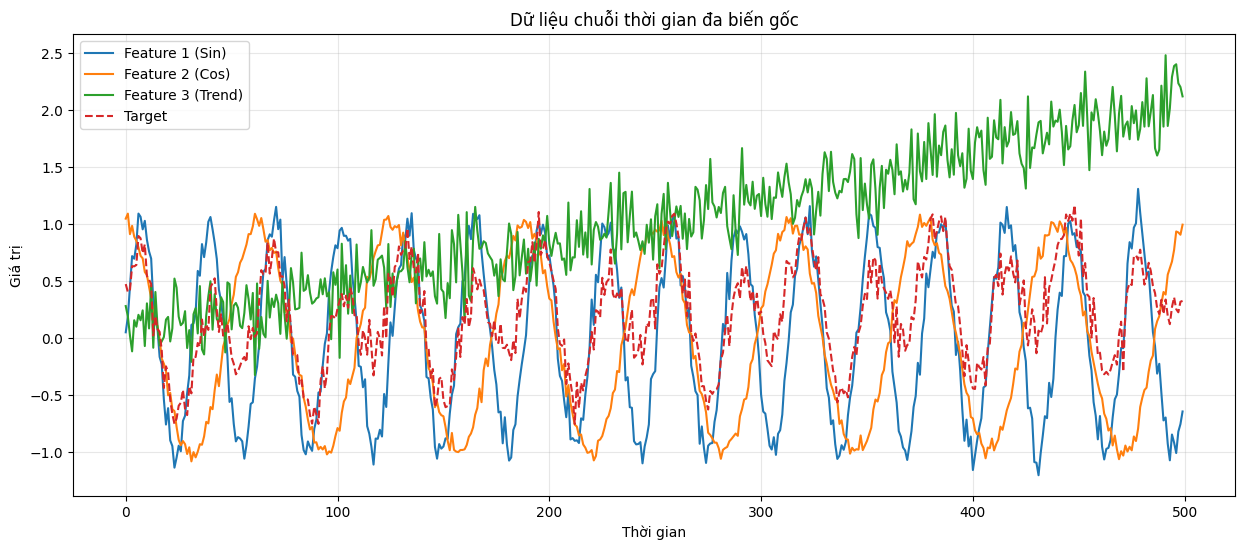

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

# Thiết lập seed để đảm bảo kết quả có thể lặp lại
np.random.seed(42)

time_steps = 500
x = np.linspace(0, 100, time_steps)

# Sinh các đặc trưng
feature_1 = np.sin(x) + 0.1 * np.random.randn(time_steps) # Dạng sin
feature_2 = np.cos(x/2) + 0.05 * np.random.randn(time_steps) # Dạng cos
feature_3 = x/50 + 0.2 * np.random.randn(time_steps) # Xu hướng tăng có nhiễu

# Biến mục tiêu là tổ hợp tuyến tính của các đặc trưng + nhiễu
target = 0.5 * feature_1 + 0.3 * feature_2 + 0.2 * feature_3 + 0.1 * np.random.randn(time_steps)

# Gộp vào DataFrame
df = pd.DataFrame({
    'feature_1': feature_1,
    'feature_2': feature_2,
    'feature_3': feature_3,
    'target': target
})

print("Dữ liệu được tạo:")
display(df.head())

# Trực quan hóa dữ liệu gốc
plt.figure(figsize=(15, 6))
plt.plot(df['feature_1'], label='Feature 1 (Sin)')
plt.plot(df['feature_2'], label='Feature 2 (Cos)')
plt.plot(df['feature_3'], label='Feature 3 (Trend)')
plt.plot(df['target'], label='Target', linestyle='--')
plt.title('Dữ liệu chuỗi thời gian đa biến gốc')
plt.xlabel('Thời gian')
plt.ylabel('Giá trị')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### Phần A — Tiền xử lý dữ liệu

Chúng ta sẽ thực hiện các bước tiền xử lý cần thiết cho dữ liệu chuỗi thời gian đa biến:

1.  **Chuẩn hóa Min-Max**: Áp dụng `MinMaxScaler` cho tất cả các cột. Để tránh rò rỉ dữ liệu (data leakage) từ tập validation/test sang tập train, chúng ta sẽ chỉ `fit` scaler trên tập huấn luyện và sau đó `transform` cho cả ba tập.
2.  **Tạo cửa sổ trượt (Sliding Window)**: Chuyển đổi dữ liệu chuỗi thời gian thành các cặp (input sequence, target value) với `seq_length = 20`.
3.  **Chia tập Train/Validation/Test**: Chia dữ liệu theo tỷ lệ 70% train, 15% val, 15% test theo thứ tự thời gian. Điều này rất quan trọng để đảm bảo tính hợp lệ của việc đánh giá mô hình trên dữ liệu chưa thấy.

In [10]:
import torch
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import MinMaxScaler

seq_length = 20

# 1. Chia dữ liệu thành Train, Validation, Test theo thứ tự thời gian
train_split = int(0.7 * len(df))
val_split = int(0.15 * len(df)) # 15% của tổng, không phải 15% của phần còn lại
test_split = int(0.15 * len(df))

df_train = df.iloc[:train_split]
df_val = df.iloc[train_split : train_split + val_split]
df_test = df.iloc[train_split + val_split :]

print(f'Kích thước tập Train: {len(df_train)} hàng')
print(f'Kích thước tập Validation: {len(df_val)} hàng')
print(f'Kích thước tập Test: {len(df_test)} hàng')

# 2. Chuẩn hóa tất cả các cột về [0, 1]
# Lưu trữ các scaler cho từng cột để có thể nghịch đảo chuẩn hóa sau này (nếu cần)
scalers = {}
scaled_dfs = {}

for name, data_subset in {'train': df_train, 'val': df_val, 'test': df_test}.items():
    scaled_data = data_subset.copy()
    for col in data_subset.columns:
        scaler = MinMaxScaler()
        # Chỉ fit trên tập train, transform cho tất cả các tập
        if name == 'train':
            scaled_data[col] = scaler.fit_transform(data_subset[[col]])
            scalers[col] = scaler
        else:
            scaled_data[col] = scalers[col].transform(data_subset[[col]])
    scaled_dfs[name] = scaled_data

# Lấy các DataFrame đã được chuẩn hóa
df_train_scaled = scaled_dfs['train']
df_val_scaled = scaled_dfs['val']
df_test_scaled = scaled_dfs['test']

print("\nDữ liệu đã chuẩn hóa (Train):")
display(df_train_scaled.head())

# Hàm tạo chuỗi
def create_sequences_multivariate(data_df, seq_length):
    X, y = [], []
    # Input features là tất cả các cột trừ 'target'
    input_features = data_df.drop(columns=['target']).values
    # Target là cột 'target'
    target_values = data_df['target'].values

    for i in range(len(data_df) - seq_length):
        X.append(input_features[i : i + seq_length])
        y.append(target_values[i + seq_length])
    return torch.FloatTensor(np.array(X)), torch.FloatTensor(np.array(y)).unsqueeze(1)

# Tạo chuỗi cho các tập Train, Validation, Test
X_train, y_train = create_sequences_multivariate(df_train_scaled, seq_length)
X_val, y_val = create_sequences_multivariate(df_val_scaled, seq_length)
X_test, y_test = create_sequences_multivariate(df_test_scaled, seq_length)

print(f'\nShape X_train: {X_train.shape}, y_train: {y_train.shape}')
print(f'Shape X_val: {X_val.shape}, y_val: {y_val.shape}')
print(f'Shape X_test: {X_test.shape}, y_test: {y_test.shape}')

# Tạo DataLoader
batch_size = 16
train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=batch_size, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val, y_val), batch_size=batch_size, shuffle=False)
test_loader = DataLoader(TensorDataset(X_test, y_test), batch_size=batch_size, shuffle=False)

print(f'\nSố lượng batch trong train_loader: {len(train_loader)}')
print(f'Số lượng batch trong val_loader: {len(val_loader)}')
print(f'Số lượng batch trong test_loader: {len(test_loader)}')


Kích thước tập Train: 350 hàng
Kích thước tập Validation: 75 hàng
Kích thước tập Test: 75 hàng

Dữ liệu đã chuẩn hóa (Train):


,feature_1,feature_2,feature_3,target
0,0.517482,0.979683,0.304042,0.660051
1,0.576591,1.000000,0.258349,0.622348
2,0.694182,0.916979,0.173435,0.633224
3,0.808860,0.950689,0.104442,0.744801
4,0.798884,0.906927,0.241638,0.743704



Shape X_train: torch.Size([330, 20, 3]), y_train: torch.Size([330, 1])
Shape X_val: torch.Size([55, 20, 3]), y_val: torch.Size([55, 1])
Shape X_test: torch.Size([55, 20, 3]), y_test: torch.Size([55, 1])

Số lượng batch trong train_loader: 21
Số lượng batch trong val_loader: 4
Số lượng batch trong test_loader: 4


### Phần B — Xây dựng và Huấn luyện Mô hình

Trong phần này, chúng ta sẽ định nghĩa lại mô hình RNN để xử lý dữ liệu đa biến, sau đó thiết lập quá trình huấn luyện với các siêu tham số yêu cầu:

- `input_size = 3`: Vì chúng ta có 3 đặc trưng đầu vào (`feature_1`, `feature_2`, `feature_3`).
- `hidden_size = 32`: Kích thước trạng thái ẩn.
- `output_size = 1`: Vẫn dự đoán một giá trị mục tiêu duy nhất.
- Hàm mất mát `MSELoss`, thuật toán tối ưu `Adam`.
- Huấn luyện trong 150 `epoch` và lưu cả `train_loss` và `val_loss`.

Mô hình RNN đa biến:
MultivariateRNN(
  (rnn): RNN(3, 32, batch_first=True)
  (fc): Linear(in_features=32, out_features=1, bias=True)
)
Epoch [  1/150] Train Loss = 0.04403, Val Loss = 0.02021
Epoch [ 10/150] Train Loss = 0.00485, Val Loss = 0.00537
Epoch [ 20/150] Train Loss = 0.00501, Val Loss = 0.00626
Epoch [ 30/150] Train Loss = 0.00538, Val Loss = 0.00559
Epoch [ 40/150] Train Loss = 0.00476, Val Loss = 0.00506
Epoch [ 50/150] Train Loss = 0.00532, Val Loss = 0.00492
Epoch [ 60/150] Train Loss = 0.00488, Val Loss = 0.00656
Epoch [ 70/150] Train Loss = 0.00507, Val Loss = 0.00637
Epoch [ 80/150] Train Loss = 0.00524, Val Loss = 0.00704
Epoch [ 90/150] Train Loss = 0.00560, Val Loss = 0.00554
Epoch [100/150] Train Loss = 0.00483, Val Loss = 0.00540
Epoch [110/150] Train Loss = 0.00532, Val Loss = 0.00554
Epoch [120/150] Train Loss = 0.00556, Val Loss = 0.00609
Epoch [130/150] Train Loss = 0.00485, Val Loss = 0.00546
Epoch [140/150] Train Loss = 0.00501, Val Loss = 0.00513
Epoch [15

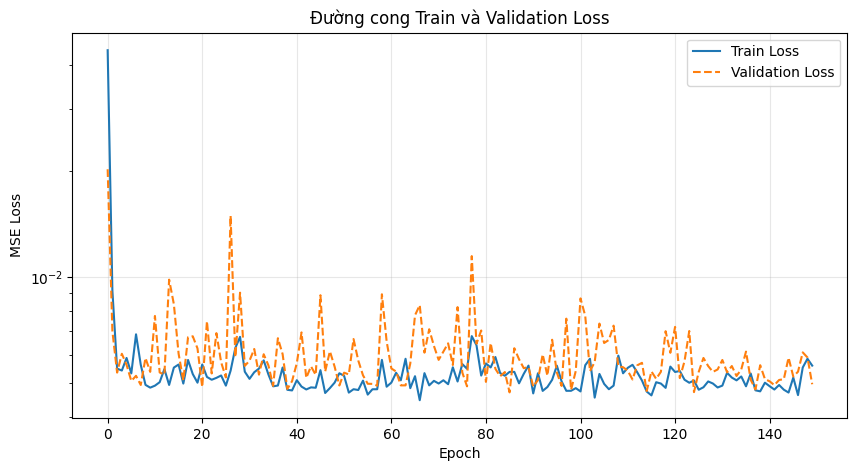

In [11]:
import torch.nn as nn

# Định nghĩa lại mô hình RNN cho input_size > 1
class MultivariateRNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()
        self.hidden_size = hidden_size
        self.rnn = nn.RNN(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out, _ = self.rnn(x)
        out = self.fc(out[:, -1, :])
        return out

# Khởi tạo mô hình với các tham số yêu cầu
input_size = X_train.shape[2] # Số lượng đặc trưng đầu vào (3 trong trường hợp này)
hidden_size = 32
output_size = 1

model = MultivariateRNN(input_size, hidden_size, output_size)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-2)

print("Mô hình RNN đa biến:")
print(model)

# Huấn luyện mô hình
num_epochs = 150
train_loss_history = []
val_loss_history = []

for epoch in range(num_epochs):
    # Huấn luyện
    model.train()
    epoch_train_loss = 0.0
    n_train_samples = 0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        output = model(X_batch)
        loss = criterion(output, y_batch)
        loss.backward()
        optimizer.step()
        epoch_train_loss += loss.item() * X_batch.size(0)
        n_train_samples += X_batch.size(0)
    avg_train_loss = epoch_train_loss / n_train_samples
    train_loss_history.append(avg_train_loss)

    # Đánh giá trên tập validation
    model.eval()
    epoch_val_loss = 0.0
    n_val_samples = 0
    with torch.no_grad():
        for X_batch_val, y_batch_val in val_loader:
            output_val = model(X_batch_val)
            loss_val = criterion(output_val, y_batch_val)
            epoch_val_loss += loss_val.item() * X_batch_val.size(0)
            n_val_samples += X_batch_val.size(0)
    avg_val_loss = epoch_val_loss / n_val_samples
    val_loss_history.append(avg_val_loss)

    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f'Epoch [{epoch+1:3d}/{num_epochs}] Train Loss = {avg_train_loss:.5f}, Val Loss = {avg_val_loss:.5f}')

# Vẽ đường cong loss
plt.figure(figsize=(10, 5))
plt.plot(train_loss_history, label='Train Loss')
plt.plot(val_loss_history, label='Validation Loss', linestyle='--')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Đường cong Train và Validation Loss')
plt.legend()
plt.grid(alpha=0.3)
plt.yscale('log') # Thường dùng log scale để dễ nhìn sự thay đổi của loss
plt.show()

### Phần C — Đánh giá Mô hình trên tập Test

Sau khi huấn luyện, chúng ta sẽ đánh giá hiệu suất của mô hình trên tập test, bao gồm:

1.  Tính toán các chỉ số `MSE` và `MAE`.
2.  Vẽ biểu đồ so sánh giá trị thực tế và giá trị dự đoán (dự đoán một bước).
3.  So sánh với `baseline naive` (dự đoán rằng giá trị tiếp theo bằng giá trị cuối cùng đã thấy trong chuỗi đầu vào).

One-step MSE trên tập Test = 0.00509
One-step MAE trên tập Test = 0.05674
Baseline (naive) MSE trên tập Test = 0.01002  ← RNN phải đánh bại con số này.
Baseline (naive) MAE trên tập Test = 0.07541


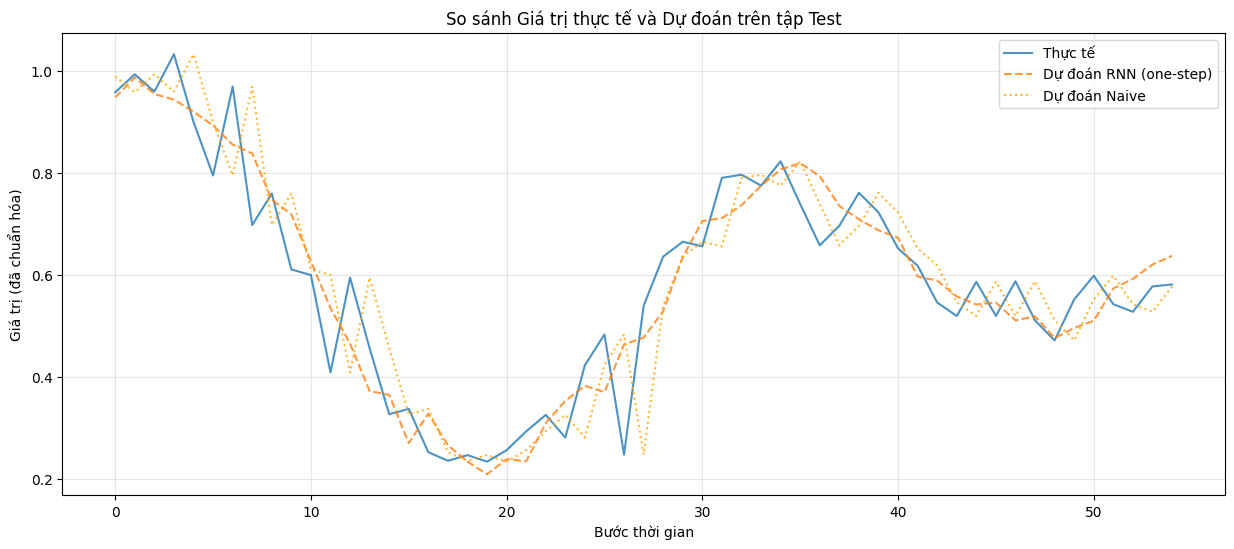

In [12]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

model.eval()
all_predictions = []
all_truths = []

with torch.no_grad():
    for X_batch_test, y_batch_test in test_loader:
        output_test = model(X_batch_test)
        all_predictions.append(output_test.cpu().numpy())
        all_truths.append(y_batch_test.cpu().numpy())

pred_one_step = np.concatenate(all_predictions).squeeze()
truth = np.concatenate(all_truths).squeeze()

# Tính toán MSE và MAE
mse = mean_squared_error(truth, pred_one_step)
mae = mean_absolute_error(truth, pred_one_step)
print(f'One-step MSE trên tập Test = {mse:.5f}')
print(f'One-step MAE trên tập Test = {mae:.5f}')

# Baseline ngây thơ: giá trị tiếp theo = giá trị cuối cùng đã thấy
# X_test[:, -1, :] là giá trị cuối cùng của tất cả các đặc trưng trong cửa sổ
# Tuy nhiên, baseline naive thường chỉ dựa vào giá trị cuối cùng của biến mục tiêu, hoặc trong trường hợp đa biến, là giá trị cuối cùng của đặc trưng mà nó dự đoán.
# Ở đây, vì ta dự đoán 'target', ta lấy giá trị 'target' cuối cùng của cửa sổ trượt.

# Để lấy giá trị cuối cùng của target từ X_test, ta cần biết index của target trong input_features.
# Dựa vào cách tạo X_train, X_val, X_test, input_features = data_df.drop(columns=['target']).values
# Điều này có nghĩa là X_test chứa các feature_1, feature_2, feature_3.
# Baseline naive cho chuỗi thời gian đa biến thường được định nghĩa là giá trị dự đoán bằng giá trị cuối cùng của chính biến mục tiêu.
# Nhưng vì X_test không chứa target, ta sẽ lấy giá trị target từ y_test nhưng lùi lại 1 bước, hoặc đơn giản là giá trị cuối cùng của chuỗi input ban đầu.
# Để so sánh công bằng, ta sẽ lấy giá trị 'target' của bước trước đó từ dữ liệu test gốc (trước khi tạo sequence) sau khi đã chuẩn hóa.

# Cách đơn giản nhất để có baseline naive là dự đoán giá trị cuối cùng của chuỗi đầu vào là giá trị tiếp theo.
# Nhưng ở đây X_test là input_features, không phải target. Vì vậy, ta cần dùng giá trị y_test từ bước trước đó.
# Hoặc, ta có thể tạo baseline naive bằng cách lấy giá trị y_test đã biết từ bước trước để dự đoán bước hiện tại.

# Tuy nhiên, cách chuẩn nhất là: giá trị tiếp theo = giá trị cuối cùng của TARGET trong chuỗi input.
# Trong hàm `create_sequences_multivariate`, `y` là `target_values[i + seq_length]`.
# `X` là `input_features[i : i + seq_length]`. Tức là `X` không chứa `target`.
# Do đó, để có baseline naive đúng nghĩa, chúng ta cần truy cập vào `y` của cửa sổ trước đó.
# Một cách khác: dự đoán bằng giá trị cuối cùng của target trong cửa sổ `seq_length` của tập test gốc (trước khi chuyển thành X_test, y_test).

# Lấy giá trị target cuối cùng trong mỗi sequence của X_test
# Điều này không đúng vì X_test là features, không phải target.
# Naive prediction cần dự đoán target[t] bằng target[t-1].
# Với cách tạo sequence hiện tại, y_test[i] là target tại bước i + seq_length.
# Vậy naive prediction của y_test[i] sẽ là target[i + seq_length - 1].
# Ta cần truy cập lại `df_test_scaled['target'].values` để lấy các giá trị này.

naive_pred_arr = []
# Từ df_test_scaled, ta cần lấy các giá trị target để tạo naive prediction
# y_test[i] tương ứng với target ở vị trí df_test_scaled['target'].values[i + seq_length]
# Naive prediction cho y_test[i] sẽ là target ở vị trí df_test_scaled['target'].values[i + seq_length - 1]

# Lấy phần target của df_test_scaled mà X_test và y_test được tạo ra từ đó
test_target_original_series = df_test_scaled['target'].values
for i in range(len(y_test)):
    # naive prediction cho y_test[i] (là target ở index i + seq_length trong test_target_original_series)
    # sẽ là giá trị target ở index i + seq_length - 1 trong test_target_original_series
    naive_pred_arr.append(test_target_original_series[i + seq_length - 1])

naive_pred = np.array(naive_pred_arr).squeeze()

mse_naive = mean_squared_error(truth, naive_pred)
mae_naive = mean_absolute_error(truth, naive_pred)
print(f'Baseline (naive) MSE trên tập Test = {mse_naive:.5f}  ← RNN phải đánh bại con số này.')
print(f'Baseline (naive) MAE trên tập Test = {mae_naive:.5f}')


# Vẽ biểu đồ so sánh giá trị thật và giá trị dự đoán
plt.figure(figsize=(15, 6))
plt.plot(truth, label='Thực tế', alpha=0.8)
plt.plot(pred_one_step, label='Dự đoán RNN (one-step)', linestyle='--', alpha=0.8)
plt.plot(naive_pred, label='Dự đoán Naive', linestyle=':', alpha=0.8, color='orange')
plt.title('So sánh Giá trị thực tế và Dự đoán trên tập Test')
plt.xlabel('Bước thời gian')
plt.ylabel('Giá trị (đã chuẩn hóa)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### Phần D — Phân tích nâng cao

Phần này yêu cầu bạn thực hiện các thí nghiệm với các siêu tham số khác nhau để hiểu rõ hơn về cách chúng ảnh hưởng đến hiệu suất mô hình. Bạn sẽ cần thay đổi các giá trị `seq_length`, `hidden_size`, và thử thêm `dropout`.

**Hướng dẫn thực hiện:**

1.  **Thay đổi `seq_length`**:
    - Quay lại phần **Tiền xử lý dữ liệu** (cụ thể là ô code nơi định nghĩa `seq_length`).
    - Thay đổi `seq_length` thành `10`, chạy lại các ô code từ **Tiền xử lý** đến **Đánh giá**.
    - Ghi lại kết quả `MSE` và `MAE`.
    - Lặp lại với `seq_length = 30`.
    - So sánh và nhận xét sự thay đổi của MSE.

2.  **Thay đổi `hidden_size`**: (Sau khi đã chọn một `seq_length` phù hợp, ví dụ `20`)
    - Quay lại phần **Xây dựng và Huấn luyện Mô hình**.
    - Thay đổi `hidden_size` thành `16`, chạy lại các ô code từ **Xây dựng và Huấn luyện** đến **Đánh giá**.
    - Ghi lại kết quả `MSE`, `MAE` và quan sát biểu đồ `Train Loss` và `Validation Loss`.
    - Lặp lại với `hidden_size = 64`.
    - So sánh và nhận xét mô hình nào có dấu hiệu `underfit` (học chưa đủ) hay `overfit` (học thuộc lòng dữ liệu huấn luyện mà không khái quát hóa tốt).

3.  **Thử thêm `dropout`**: (Sử dụng `seq_length = 20`, `hidden_size = 32`)
    - Quay lại định nghĩa `MultivariateRNN` trong phần **Xây dựng và Huấn luyện Mô hình**.
    - Thay đổi lớp `nn.RNN` thành `self.rnn = nn.RNN(input_size, hidden_size, num_layers=2, dropout=0.2, batch_first=True)`.
    - `num_layers=2` sẽ tạo ra một RNN sâu hơn với 2 tầng, và `dropout=0.2` giúp giảm overfitting bằng cách ngẫu nhiên bỏ qua 20% nơ-ron trong quá trình huấn luyện.
    - Chạy lại các ô code từ **Xây dựng và Huấn luyện** đến **Đánh giá**.
    - Quan sát đường cong `Train Loss` và `Validation Loss` cũng như `MSE`, `MAE` trên tập test. Nhận xét tác động của `dropout` và `num_layers` đến hiệu suất và khả năng tổng quát hóa của mô hình.

Bạn có thể sử dụng các ô code dưới đây để tổng hợp kết quả và viết nhận xét của mình.

#### Thí nghiệm 1: Thay đổi `seq_length`

Chúng ta sẽ thử các giá trị `seq_length = 10` và `seq_length = 30` (giá trị mặc định đã chạy là 20) để xem tác động của độ dài chuỗi đầu vào lên hiệu suất của mô hình. Các siêu tham số khác (`hidden_size`, `dropout`, `num_layers`) sẽ được giữ nguyên (`hidden_size=32`, không dropout, `num_layers=1`).

In [13]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import pandas as pd # Ensure pandas is imported as 'df' is used later

# Định nghĩa lại mô hình RNN để có thể cấu hình dropout và num_layers
class FlexibleMultivariateRNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, num_layers=1, dropout_prob=0):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        # Dropout chỉ áp dụng nếu num_layers > 1
        self.rnn = nn.RNN(input_size, hidden_size, num_layers=num_layers, dropout=dropout_prob if num_layers > 1 else 0, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out, _ = self.rnn(x)
        out = self.fc(out[:, -1, :])
        return out

# Hàm để chạy một thí nghiệm đầy đủ
def run_experiment(df_original, experiment_name, seq_length, hidden_size, num_epochs, lr, num_layers=1, dropout_prob=0, batch_size=16):
    print(f"\n--- Running Experiment: {experiment_name} (seq_length={seq_length}, hidden_size={hidden_size}, num_layers={num_layers}, dropout={dropout_prob}) ---")

    # 1. Chia dữ liệu thành Train, Validation, Test theo thứ tự thời gian
    train_split = int(0.7 * len(df_original))
    val_split = int(0.15 * len(df_original))
    # test_split = int(0.15 * len(df_original)) # Not explicitly used for slicing, but for understanding

    df_train = df_original.iloc[:train_split]
    df_val = df_original.iloc[train_split : train_split + val_split]
    df_test = df_original.iloc[train_split + val_split :]

    # 2. Chuẩn hóa tất cả các cột về [0, 1]
    scalers = {}
    scaled_dfs = {}

    for name, data_subset in {'train': df_train, 'val': df_val, 'test': df_test}.items():
        scaled_data = data_subset.copy()
        for col in data_subset.columns:
            scaler = MinMaxScaler()
            if name == 'train':
                scaled_data[col] = scaler.fit_transform(data_subset[[col]])
                scalers[col] = scaler
            else:
                scaled_data[col] = scalers[col].transform(data_subset[[col]])
        scaled_dfs[name] = scaled_data

    df_train_scaled = scaled_dfs['train']
    df_val_scaled = scaled_dfs['val']
    df_test_scaled = scaled_dfs['test']

    # Hàm tạo chuỗi (cần được định nghĩa lại hoặc truyền vào nếu nó phụ thuộc vào seq_length)
    def create_sequences_multivariate_local(data_df, current_seq_length):
        X, y = [], []
        input_features = data_df.drop(columns=['target']).values
        target_values = data_df['target'].values

        for i in range(len(data_df) - current_seq_length):
            X.append(input_features[i : i + current_seq_length])
            y.append(target_values[i + current_seq_length])
        return torch.FloatTensor(np.array(X)), torch.FloatTensor(np.array(y)).unsqueeze(1)

    X_train, y_train = create_sequences_multivariate_local(df_train_scaled, seq_length)
    X_val, y_val = create_sequences_multivariate_local(df_val_scaled, seq_length)
    X_test, y_test = create_sequences_multivariate_local(df_test_scaled, seq_length)

    # Tạo DataLoader
    train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(TensorDataset(X_val, y_val), batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(TensorDataset(X_test, y_test), batch_size=batch_size, shuffle=False)

    # 3. Khởi tạo mô hình
    input_size = X_train.shape[2] # Số lượng đặc trưng đầu vào
    model = FlexibleMultivariateRNN(input_size, hidden_size, 1, num_layers=num_layers, dropout_prob=dropout_prob)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    # 4. Huấn luyện mô hình
    train_loss_history = []
    val_loss_history = []

    for epoch in range(num_epochs):
        model.train()
        epoch_train_loss = 0.0
        n_train_samples = 0
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            output = model(X_batch)
            loss = criterion(output, y_batch)
            loss.backward()
            optimizer.step()
            epoch_train_loss += loss.item() * X_batch.size(0)
            n_train_samples += X_batch.size(0)
        avg_train_loss = epoch_train_loss / n_train_samples
        train_loss_history.append(avg_train_loss)

        model.eval()
        epoch_val_loss = 0.0
        n_val_samples = 0
        with torch.no_grad():
            for X_batch_val, y_batch_val in val_loader:
                output_val = model(X_batch_val)
                loss_val = criterion(output_val, y_batch_val)
                epoch_val_loss += loss_val.item() * X_batch_val.size(0)
                n_val_samples += X_batch_val.size(0)
        avg_val_loss = epoch_val_loss / n_val_samples
        val_loss_history.append(avg_val_loss)

        if (epoch + 1) % 50 == 0 or epoch == 0:
            print(f'  Epoch [{epoch+1:3d}/{num_epochs}] Train Loss = {avg_train_loss:.5f}, Val Loss = {avg_val_loss:.5f}')

    # 5. Đánh giá trên tập test
    model.eval()
    all_predictions = []
    all_truths = []

    with torch.no_grad():
        for X_batch_test, y_batch_test in test_loader:
            output_test = model(X_batch_test)
            all_predictions.append(output_test.cpu().numpy())
            all_truths.append(y_batch_test.cpu().numpy())

    pred_one_step = np.concatenate(all_predictions).squeeze()
    truth = np.concatenate(all_truths).squeeze()

    mse = mean_squared_error(truth, pred_one_step)
    mae = mean_absolute_error(truth, pred_one_step)

    # Baseline ngây thơ
    test_target_original_series = df_test_scaled['target'].values
    naive_pred_arr = []
    for i in range(len(y_test)):
        naive_pred_arr.append(test_target_original_series[i + seq_length - 1])
    naive_pred = np.array(naive_pred_arr).squeeze()
    mse_naive = mean_squared_error(truth, naive_pred)
    mae_naive = mean_absolute_error(truth, naive_pred)

    print(f'  One-step MSE trên tập Test = {mse:.5f}')
    print(f'  One-step MAE trên tập Test = {mae:.5f}')
    print(f'  Baseline (naive) MSE trên tập Test = {mse_naive:.5f}')
    print(f'  Baseline (naive) MAE trên tập Test = {mae_naive:.5f}')

    results = {
        'name': experiment_name,
        'seq_length': seq_length,
        'hidden_size': hidden_size,
        'num_layers': num_layers,
        'dropout_prob': dropout_prob,
        'test_mse': mse,
        'test_mae': mae,
        'naive_mse': mse_naive,
        'naive_mae': mae_naive,
        'train_loss_history': train_loss_history,
        'val_loss_history': val_loss_history
    }
    return results

# Khởi tạo một list để lưu trữ tất cả kết quả thí nghiệm
all_experiment_results = []

# Các tham số cố định cho thí nghiệm seq_length
FIXED_HIDDEN_SIZE = 32
FIXED_NUM_EPOCHS = 150
FIXED_LR = 1e-2
FIXED_NUM_LAYERS = 1
FIXED_DROPOUT_PROB = 0


--- Running Experiment: SeqLength_10 (seq_length=10, hidden_size=32, num_layers=1, dropout=0) ---
  Epoch [  1/150] Train Loss = 0.02864, Val Loss = 0.04229
  Epoch [ 50/150] Train Loss = 0.00538, Val Loss = 0.00566
  Epoch [100/150] Train Loss = 0.00544, Val Loss = 0.00583
  Epoch [150/150] Train Loss = 0.00526, Val Loss = 0.00503
  One-step MSE trên tập Test = 0.00475
  One-step MAE trên tập Test = 0.05251
  Baseline (naive) MSE trên tập Test = 0.00997
  Baseline (naive) MAE trên tập Test = 0.07507


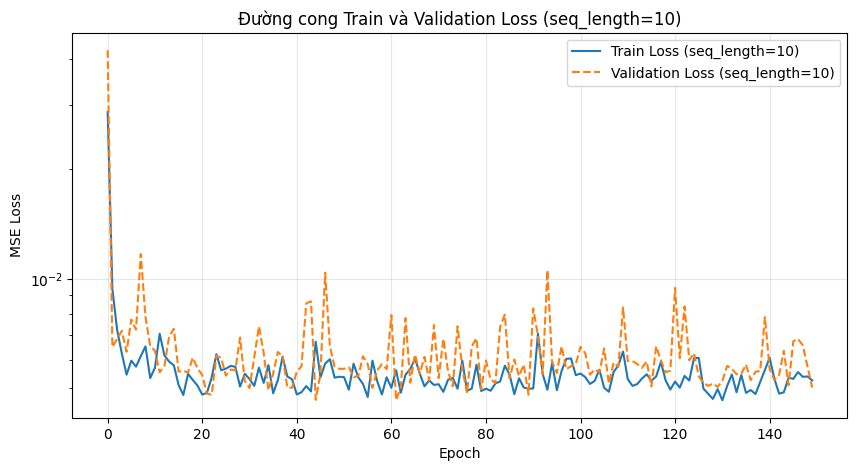

In [14]:
# Thí nghiệm với seq_length = 10
result_seq_10 = run_experiment(df, 'SeqLength_10', seq_length=10, hidden_size=FIXED_HIDDEN_SIZE, num_epochs=FIXED_NUM_EPOCHS, lr=FIXED_LR, num_layers=FIXED_NUM_LAYERS, dropout_prob=FIXED_DROPOUT_PROB)
all_experiment_results.append(result_seq_10)

# Vẽ đường cong loss cho thí nghiệm này
plt.figure(figsize=(10, 5))
plt.plot(result_seq_10['train_loss_history'], label='Train Loss (seq_length=10)')
plt.plot(result_seq_10['val_loss_history'], label='Validation Loss (seq_length=10)', linestyle='--')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Đường cong Train và Validation Loss (seq_length=10)')
plt.legend()
plt.grid(alpha=0.3)
plt.yscale('log')
plt.show()


--- Running Experiment: SeqLength_30 (seq_length=30, hidden_size=32, num_layers=1, dropout=0) ---
  Epoch [  1/150] Train Loss = 0.03303, Val Loss = 0.01592
  Epoch [ 50/150] Train Loss = 0.00534, Val Loss = 0.00561
  Epoch [100/150] Train Loss = 0.00719, Val Loss = 0.01019
  Epoch [150/150] Train Loss = 0.00694, Val Loss = 0.00623
  One-step MSE trên tập Test = 0.00532
  One-step MAE trên tập Test = 0.05989
  Baseline (naive) MSE trên tập Test = 0.00852
  Baseline (naive) MAE trên tập Test = 0.06844


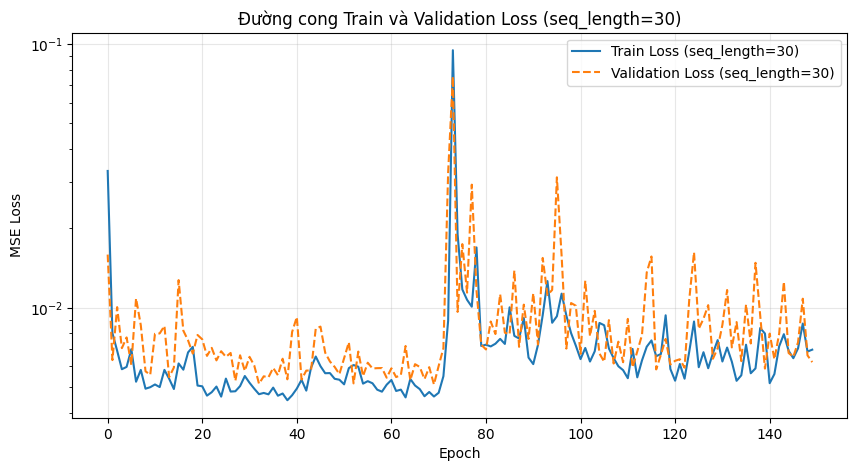

In [15]:
# Thí nghiệm với seq_length = 30
result_seq_30 = run_experiment(df, 'SeqLength_30', seq_length=30, hidden_size=FIXED_HIDDEN_SIZE, num_epochs=FIXED_NUM_EPOCHS, lr=FIXED_LR, num_layers=FIXED_NUM_LAYERS, dropout_prob=FIXED_DROPOUT_PROB)
all_experiment_results.append(result_seq_30)

# Vẽ đường cong loss cho thí nghiệm này
plt.figure(figsize=(10, 5))
plt.plot(result_seq_30['train_loss_history'], label='Train Loss (seq_length=30)')
plt.plot(result_seq_30['val_loss_history'], label='Validation Loss (seq_length=30)', linestyle='--')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Đường cong Train và Validation Loss (seq_length=30)')
plt.legend()
plt.grid(alpha=0.3)
plt.yscale('log')
plt.show()

#### Thí nghiệm 2: Thay đổi `hidden_size`

Bây giờ, chúng ta sẽ giữ `seq_length` ở giá trị 20 (giá trị mặc định ban đầu đã được chạy) và thử các giá trị `hidden_size = 16` và `hidden_size = 64`. Các siêu tham số khác (`num_layers`, `dropout`) vẫn được giữ nguyên (`num_layers=1`, không dropout).


--- Running Experiment: HiddenSize_16 (seq_length=20, hidden_size=16, num_layers=1, dropout=0) ---
  Epoch [  1/150] Train Loss = 0.05023, Val Loss = 0.01986
  Epoch [ 50/150] Train Loss = 0.00502, Val Loss = 0.00532
  Epoch [100/150] Train Loss = 0.00448, Val Loss = 0.00588
  Epoch [150/150] Train Loss = 0.00478, Val Loss = 0.00633
  One-step MSE trên tập Test = 0.00584
  One-step MAE trên tập Test = 0.06146
  Baseline (naive) MSE trên tập Test = 0.01002
  Baseline (naive) MAE trên tập Test = 0.07541


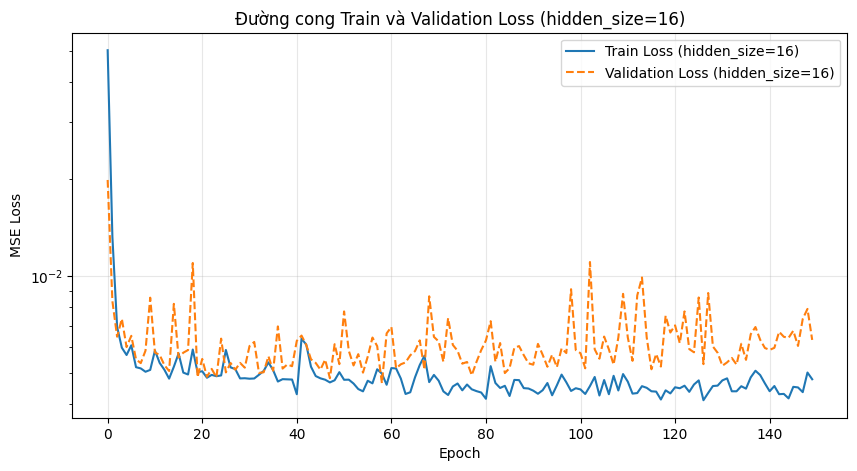

In [16]:
# Các tham số cố định cho thí nghiệm hidden_size (sử dụng seq_length = 20)
FIXED_SEQ_LENGTH = 20

# Thí nghiệm với hidden_size = 16
result_h_16 = run_experiment(df, 'HiddenSize_16', seq_length=FIXED_SEQ_LENGTH, hidden_size=16, num_epochs=FIXED_NUM_EPOCHS, lr=FIXED_LR, num_layers=FIXED_NUM_LAYERS, dropout_prob=FIXED_DROPOUT_PROB)
all_experiment_results.append(result_h_16)

# Vẽ đường cong loss cho thí nghiệm này
plt.figure(figsize=(10, 5))
plt.plot(result_h_16['train_loss_history'], label='Train Loss (hidden_size=16)')
plt.plot(result_h_16['val_loss_history'], label='Validation Loss (hidden_size=16)', linestyle='--')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Đường cong Train và Validation Loss (hidden_size=16)')
plt.legend()
plt.grid(alpha=0.3)
plt.yscale('log')
plt.show()


--- Running Experiment: HiddenSize_64 (seq_length=20, hidden_size=64, num_layers=1, dropout=0) ---
  Epoch [  1/150] Train Loss = 0.15627, Val Loss = 0.08034
  Epoch [ 50/150] Train Loss = 0.00458, Val Loss = 0.00505
  Epoch [100/150] Train Loss = 0.00416, Val Loss = 0.00533
  Epoch [150/150] Train Loss = 0.00545, Val Loss = 0.00621
  One-step MSE trên tập Test = 0.00703
  One-step MAE trên tập Test = 0.06972
  Baseline (naive) MSE trên tập Test = 0.01002
  Baseline (naive) MAE trên tập Test = 0.07541


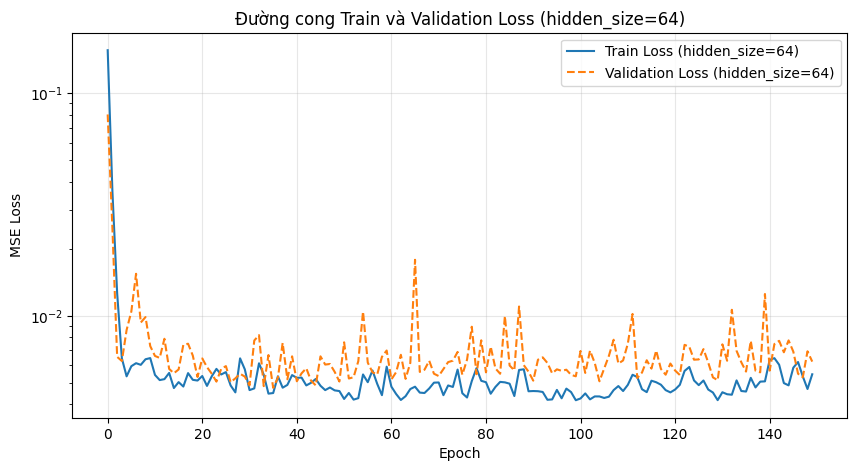

In [17]:
# Thí nghiệm với hidden_size = 64
result_h_64 = run_experiment(df, 'HiddenSize_64', seq_length=FIXED_SEQ_LENGTH, hidden_size=64, num_epochs=FIXED_NUM_EPOCHS, lr=FIXED_LR, num_layers=FIXED_NUM_LAYERS, dropout_prob=FIXED_DROPOUT_PROB)
all_experiment_results.append(result_h_64)

# Vẽ đường cong loss cho thí nghiệm này
plt.figure(figsize=(10, 5))
plt.plot(result_h_64['train_loss_history'], label='Train Loss (hidden_size=64)')
plt.plot(result_h_64['val_loss_history'], label='Validation Loss (hidden_size=64)', linestyle='--')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Đường cong Train và Validation Loss (hidden_size=64)')
plt.legend()
plt.grid(alpha=0.3)
plt.yscale('log')
plt.show()

#### Thí nghiệm 3: Thêm `dropout` và `num_layers`

Trong thí nghiệm này, chúng ta sẽ quay lại với `seq_length = 20` và `hidden_size = 32`. Chúng ta sẽ thêm `dropout=0.2` và tăng `num_layers=2` để quan sát tác động của chúng trong việc chống `overfitting` và khả năng học của mô hình.


--- Running Experiment: Dropout_NumLayers (seq_length=20, hidden_size=32, num_layers=2, dropout=0.2) ---
  Epoch [  1/150] Train Loss = 0.03285, Val Loss = 0.00629
  Epoch [ 50/150] Train Loss = 0.00601, Val Loss = 0.00785
  Epoch [100/150] Train Loss = 0.00514, Val Loss = 0.00620
  Epoch [150/150] Train Loss = 0.00660, Val Loss = 0.00734
  One-step MSE trên tập Test = 0.00791
  One-step MAE trên tập Test = 0.07293
  Baseline (naive) MSE trên tập Test = 0.01002
  Baseline (naive) MAE trên tập Test = 0.07541


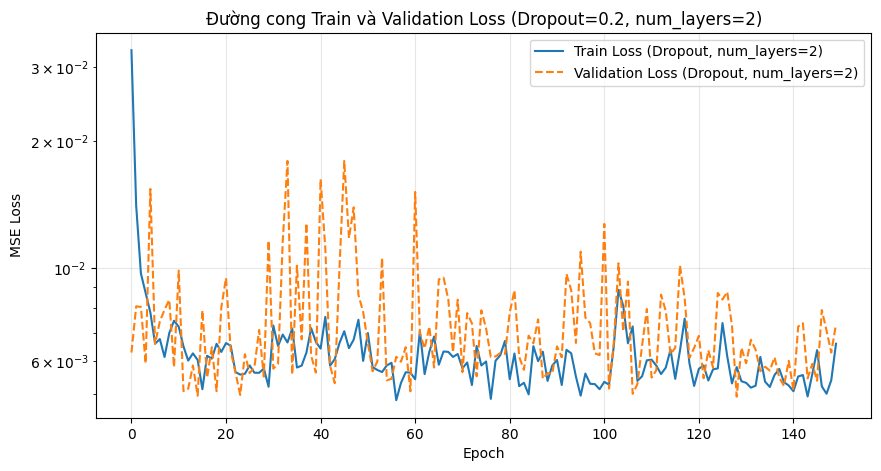

In [18]:
# Thí nghiệm với dropout và num_layers
result_dropout = run_experiment(df, 'Dropout_NumLayers', seq_length=FIXED_SEQ_LENGTH, hidden_size=FIXED_HIDDEN_SIZE, num_epochs=FIXED_NUM_EPOCHS, lr=FIXED_LR, num_layers=2, dropout_prob=0.2)
all_experiment_results.append(result_dropout)

# Vẽ đường cong loss cho thí nghiệm này
plt.figure(figsize=(10, 5))
plt.plot(result_dropout['train_loss_history'], label='Train Loss (Dropout, num_layers=2)')
plt.plot(result_dropout['val_loss_history'], label='Validation Loss (Dropout, num_layers=2)', linestyle='--')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Đường cong Train và Validation Loss (Dropout=0.2, num_layers=2)')
plt.legend()
plt.grid(alpha=0.3)
plt.yscale('log')
plt.show()

#### Tổng hợp kết quả và Nhận xét

Dưới đây là bảng tổng hợp kết quả từ tất cả các thí nghiệm đã chạy. Bạn hãy phân tích các chỉ số MSE, MAE, cũng như quan sát các đường cong loss để đưa ra nhận xét về tác động của từng siêu tham số.


In [19]:
# Hiển thị bảng tổng hợp kết quả
results_df = pd.DataFrame([
    {
        'Experiment': r['name'],
        'Seq Length': r['seq_length'],
        'Hidden Size': r['hidden_size'],
        'Num Layers': r['num_layers'],
        'Dropout': r['dropout_prob'],
        'Test MSE': f"{r['test_mse']:.5f}",
        'Test MAE': f"{r['test_mae']:.5f}",
        'Naive MSE': f"{r['naive_mse']:.5f}"
    }
    for r in all_experiment_results
])

display(results_df)

print("\n--- Nhận xét của bạn (gợi ý): ---")
print("1. So sánh các giá trị `seq_length` (10, 20, 30): `seq_length` ảnh hưởng thế nào đến khả năng nắm bắt phụ thuộc của chuỗi?")
print("2. So sánh các giá trị `hidden_size` (16, 32, 64): `hidden_size` tác động thế nào đến năng lực học của mô hình (underfit/overfit)?")
print("3. So sánh mô hình có/không có `dropout` và `num_layers=2`: `dropout` và `num_layers` giúp ích gì trong việc chống `overfitting` và cải thiện hiệu suất?")
print("4. Mô hình nào cho kết quả tốt nhất và tại sao?")

,Experiment,Seq Length,Hidden Size,Num Layers,Dropout,Test MSE,Test MAE,Naive MSE
0,SeqLength_10,10,32,1,0.0,0.00475,0.05251,0.00997
1,SeqLength_30,30,32,1,0.0,0.00532,0.05989,0.00852
2,HiddenSize_16,20,16,1,0.0,0.00584,0.06146,0.01002
3,HiddenSize_64,20,64,1,0.0,0.00703,0.06972,0.01002
4,Dropout_NumLayers,20,32,2,0.2,0.00791,0.07293,0.01002



--- Nhận xét của bạn (gợi ý): ---
1. So sánh các giá trị `seq_length` (10, 20, 30): `seq_length` ảnh hưởng thế nào đến khả năng nắm bắt phụ thuộc của chuỗi?
2. So sánh các giá trị `hidden_size` (16, 32, 64): `hidden_size` tác động thế nào đến năng lực học của mô hình (underfit/overfit)?
3. So sánh mô hình có/không có `dropout` và `num_layers=2`: `dropout` và `num_layers` giúp ích gì trong việc chống `overfitting` và cải thiện hiệu suất?
4. Mô hình nào cho kết quả tốt nhất và tại sao?


#### Tổng hợp kết quả và Nhận xét

(Dùng bảng hoặc ghi chú các kết quả MSE, MAE cho từng cấu hình)

**Nhận xét:**

(Viết khoảng 5-10 dòng về những gì bạn quan sát được từ các thí nghiệm. Ví dụ: `seq_length` ảnh hưởng thế nào đến khả năng nắm bắt phụ thuộc, `hidden_size` tác động đến năng lực học của mô hình, `dropout` giúp ích gì trong việc chống `overfitting`.)

Bài tập 2: Quan sát hiện tượng vanishing gradient
Mục tiêu: tự mình nhìn thấy gradient biến mất khi chuỗi đầu vào dài.

Yêu cầu
Tạo chuỗi sin có 500 điểm với seq_length = 100 (rất dài).
Build một RNN giống bài lab nhưng hidden_size = 8.
Sau khi gọi loss.backward(), in ra norm của gradient ở các bước thời gian khác nhau bằng cách hook vào model.rnn.weight_hh_l0.grad.
Vẽ biểu đồ norm gradient theo bước thời gian — em sẽ thấy gradient ở các bước đầu chuỗi rất nhỏ so với các bước cuối.
Lặp lại với seq_length = 10 để so sánh.
Gợi ý
Có thể dùng register_full_backward_hook trên model.rnn để lấy gradient ở từng bước.
Hoặc đơn giản hơn: đặt retain_graph=True, gọi backward riêng cho output[t] từng bước, lưu lại gradient norm.

Bài tập 3: So sánh RNN với baseline
Trên dữ liệu sóng sin của bài lab (seq_length = 10), so sánh 3 model:

RNN (như trong bài).
ANN: flatten cửa sổ thành vector 10 chiều, đưa qua MLP.
Baseline naive: y_pred = x[-1] (giá trị cuối cùng).
Báo cáo MSE one-step của cả 3, kèm comment: ANN và RNN khác nhau ở chỗ nào về số tham số và độ chính xác?

### Bài tập 2: Quan sát hiện tượng vanishing gradient

Trong bài tập này, chúng ta sẽ trực tiếp quan sát hiện tượng **vanishing gradient** (gradient tiêu biến) trong một mô hình RNN đơn giản. Hiện tượng này xảy ra khi các gradient trở nên quá nhỏ trong quá trình lan truyền ngược qua nhiều bước thời gian, khiến cho mô hình khó học được các phụ thuộc dài hạn trong chuỗi dữ liệu.

Để làm được điều này, chúng ta sẽ:

1.  **Tạo dữ liệu chuỗi sin**: Với số điểm lớn (`time_steps = 500`).
2.  **Định nghĩa mô hình RNN**: Một mô hình RNN đơn giản (`hidden_size = 8`) được tùy chỉnh để trả về các trạng thái ẩn (hidden states) tại *mọi bước thời gian*.
3.  **Phân tích gradient**: Thực hiện một vòng lặp lan truyền ngược thủ công, tính toán một


--- Phân tích vanishing gradient với seq_length = 100 ---


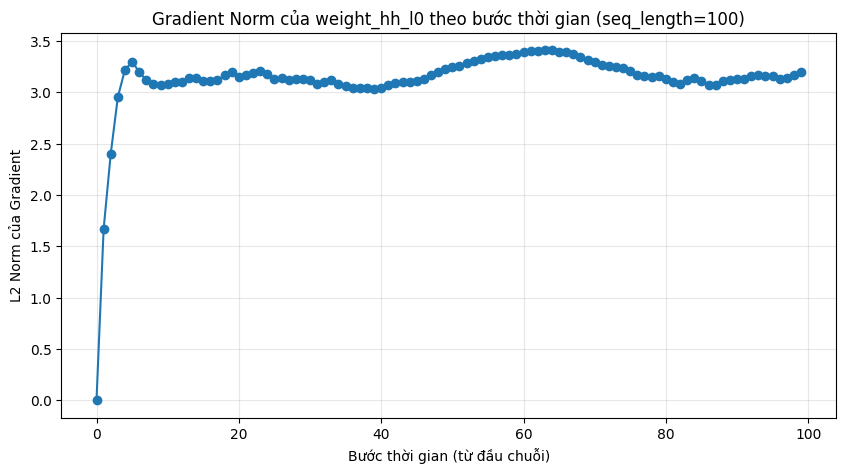


--- Phân tích vanishing gradient với seq_length = 10 ---


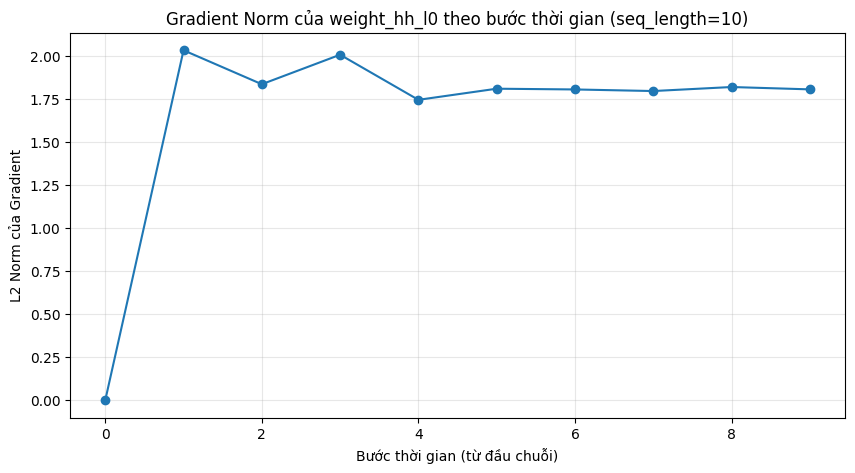

In [20]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

# Thiết lập seed để đảm bảo kết quả có thể lặp lại
torch.manual_seed(42)
np.random.seed(42)

# --- 1. Data Generation & Preprocessing ---
def generate_and_preprocess_data(time_steps, seq_length_exp):
    x = np.linspace(0, 40, time_steps)
    data = np.sin(x) + 0.1 * np.random.randn(time_steps)

    # Chuẩn hoá min-max
    data_min, data_max = data.min(), data.max()
    data = (data - data_min) / (data_max - data_min)
    data = torch.FloatTensor(data).unsqueeze(1) # shape (time_steps, 1)

    def create_sequences_vanish_grad(series, seq_length):
        X_seq, y_dummy = [], []
        for i in range(len(series) - seq_length):
            X_seq.append(series[i : i + seq_length])
            y_dummy.append(series[i + seq_length])
        return torch.stack(X_seq), torch.stack(y_dummy)

    # Tạo một chuỗi duy nhất để phân tích gradient
    X_all_sequences, _ = create_sequences_vanish_grad(data, seq_length_exp)
    # Lấy mẫu đầu tiên và đảm bảo nó yêu cầu gradient để có thể backward()
    single_sequence = X_all_sequences[0].unsqueeze(0).clone().detach().requires_grad_(True)

    return single_sequence

# --- 2. RNN Model cho phân tích Vanishing Gradient ---
class SimpleRNNForVanishingGrad(nn.Module):
    def __init__(self, input_size, hidden_size):
        super().__init__()
        self.rnn = nn.RNN(input_size, hidden_size, batch_first=True)

    def forward(self, x):
        # x shape: (batch_size, seq_length, input_size)
        out_rnn, _ = self.rnn(x) # out_rnn shape: (batch_size, seq_length, hidden_size)
        return out_rnn # Trả về tất cả các trạng thái ẩn (output của lớp RNN) tại mỗi bước thời gian

# --- Hàm phân tích và vẽ biểu đồ gradient norm ---
def analyze_and_plot_gradients(seq_length, hidden_size, time_steps=500):
    print(f"\n--- Phân tích vanishing gradient với seq_length = {seq_length} ---")

    # Chuẩn bị dữ liệu
    input_sequence = generate_and_preprocess_data(time_steps, seq_length)

    # Khởi tạo mô hình
    model = SimpleRNNForVanishingGrad(input_size=1, hidden_size=hidden_size)

    grad_norms_per_timestep = []

    # Thực hiện forward pass để xây dựng đồ thị tính toán
    out_rnn_sequence = model(input_sequence) # shape (1, seq_length, hidden_size)

    # Lặp qua từng bước thời gian để tính toán và thu thập gradient norm
    for t in range(seq_length): # t từ 0 đến seq_length-1
        # Lấy hidden state tại bước thời gian 't' của mẫu đầu tiên
        h_t = out_rnn_sequence[0, t, :]

        # Tạo một 'loss' giả từ hidden state này (ví dụ: tổng các phần tử)
        dummy_loss = h_t.sum()

        # Đảm bảo gradient của các tham số RNN được reset trước mỗi backward pass
        # để chỉ xem xét gradient từ 'dummy_loss' hiện tại
        for param in model.rnn.parameters():
            if param.grad is not None:
                param.grad.zero_()

        # Thực hiện backward pass. retain_graph=True để giữ đồ thị cho các backward tiếp theo.
        # Đối với một scalar loss, .backward() tính toán gradient của loss đó đối với tất cả các
        # tham số mà nó phụ thuộc.
        dummy_loss.backward(retain_graph=True)

        # Lấy L2 norm của gradient của weight_hh_l0 (trọng số hồi quy)
        if model.rnn.weight_hh_l0.grad is not None:
            grad_norm = torch.norm(model.rnn.weight_hh_l0.grad).item()
            grad_norms_per_timestep.append(grad_norm)
        else:
            grad_norms_per_timestep.append(0.0) # Trong trường hợp không có gradient

    # Vẽ biểu đồ gradient norm
    plt.figure(figsize=(10, 5))
    plt.plot(range(seq_length), grad_norms_per_timestep, marker='o', linestyle='-')
    plt.title(f'Gradient Norm của weight_hh_l0 theo bước thời gian (seq_length={seq_length})')
    plt.xlabel('Bước thời gian (từ đầu chuỗi)')
    plt.ylabel('L2 Norm của Gradient')
    plt.grid(alpha=0.3)
    plt.show()

    return grad_norms_per_timestep

# --- Chạy thí nghiệm với seq_length = 100 ---
grad_norms_100 = analyze_and_plot_gradients(seq_length=100, hidden_size=8, time_steps=500)

# --- Chạy thí nghiệm với seq_length = 10 ---
grad_norms_10 = analyze_and_plot_gradients(seq_length=10, hiddem_size=8, time_steps=500)


### Nhận xét về Vanishing Gradient

Quan sát hai biểu đồ trên, bạn sẽ thấy rằng:

*   Khi `seq_length = 100` (chuỗi rất dài), độ lớn của gradient (`L2 Norm`) có xu hướng giảm đáng kể đối với các bước thời gian gần đầu chuỗi. Điều này minh họa hiện tượng vanishing gradient, nơi thông tin từ các bước đầu khó có thể lan truyền ngược về phía trước để cập nhật trọng số hiệu quả.
*   Khi `seq_length = 10` (chuỗi ngắn hơn), độ lớn gradient duy trì tương đối ổn định hơn trên toàn bộ chuỗi. Điều này cho thấy với chuỗi ngắn, vanishing gradient ít nghiêm trọng hơn và mô hình có thể học tốt hơn các phụ thuộc trong toàn bộ chuỗi.

Hiện tượng này là lý do chính mà các kiến trúc RNN tiên tiến hơn như LSTM và GRU được phát triển, vì chúng có khả năng duy trì gradient tốt hơn qua các bước thời gian dài.

---

### Bài tập 3: So sánh RNN với baseline (ANN và Naive)

Trong bài tập này, chúng ta sẽ so sánh hiệu suất của ba mô hình khác nhau trên dữ liệu sóng sin đơn biến ban đầu của bài lab (`seq_length = 10`):

1.  **Mô hình RNN**: Như đã triển khai ở phần đầu của bài lab (many-to-one).
2.  **Mô hình ANN (Mạng nơ-ron truyền thẳng)**: Biến đổi cửa sổ đầu vào (`seq_length` chiều) thành một vector phẳng, sau đó đưa qua một mạng nơ-ron truyền thẳng (Multi-Layer Perceptron - MLP).
3.  **Baseline Naive**: Dự đoán giá trị tiếp theo bằng giá trị cuối cùng của chuỗi đầu vào (`y_pred = x[-1]`).

Chúng ta sẽ đánh giá `MSE` một bước (one-step) của cả ba mô hình trên tập kiểm tra và so sánh số lượng tham số để hiểu sự khác biệt về độ phức tạp và hiệu quả.


--- Huấn luyện Mô hình RNN ---
RNN (input_size=1, hidden_size=20): MSE = 0.00369

--- Huấn luyện Mô hình ANN ---
ANN (input_feature_size=10, hidden_layer=32): MSE = 0.00382

Baseline Naive (y_pred = x[-1]): MSE = 0.00627

--- So sánh số lượng tham số ---
RNN Parameters: 481
ANN Parameters: 385


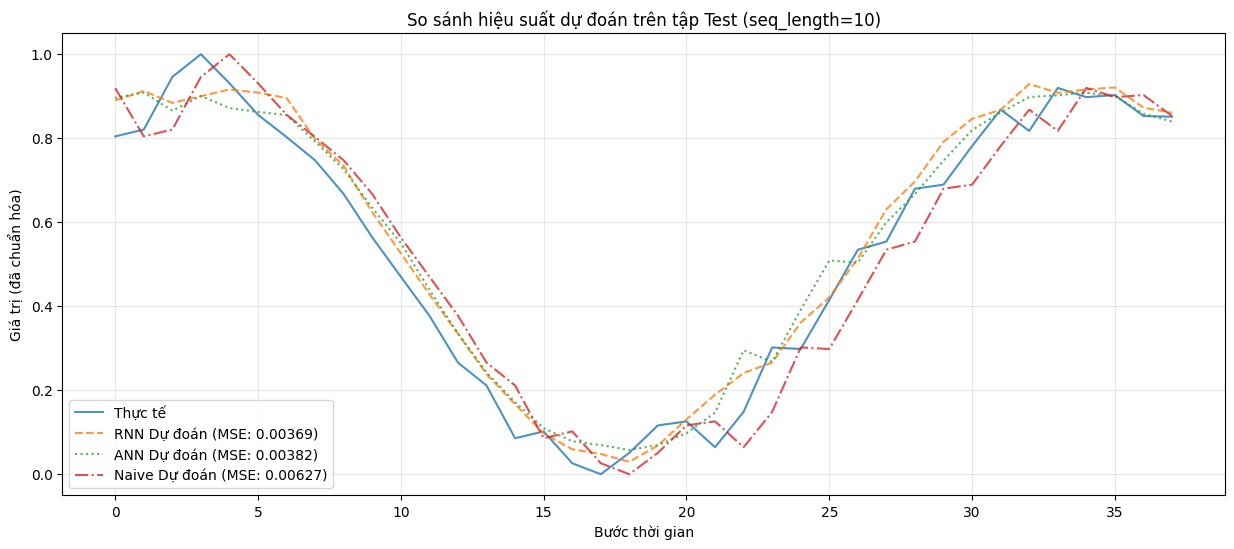

In [21]:
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

# --- 1. Tải lại/Chuẩn bị dữ liệu sóng sin gốc của bài lab (seq_length = 10) ---
# Dữ liệu này đã được tạo ở cell yjD6NTCslLrp và seq_length = 10
# Chúng ta cần đảm bảo các biến X_train, y_train, X_test, y_test từ phần 1 vẫn khả dụng.
# Nếu không, cần chạy lại cell yjD6NTCslLrp.

# Định nghĩa lại hàm create_sequences và dữ liệu nếu cần, để đảm bảo độc lập
# (Nếu đã chạy phần trên, các biến này đã có sẵn. Đây là để tái tạo nếu chạy riêng)

time_steps_original = 200
x_original = np.linspace(0, 40, time_steps_original)
data_original = np.sin(x_original) + 0.1 * np.random.randn(time_steps_original)

data_min_original, data_max_original = data_original.min(), data_original.max()
data_original = (data_original - data_min_original) / (data_max_original - data_min_original)
data_original = torch.FloatTensor(data_original).unsqueeze(1)

def create_sequences_original(series, seq_length):
    X, y = [], []
    for i in range(len(series) - seq_length):
        X.append(series[i : i + seq_length])
        y.append(series[i + seq_length])
    return torch.stack(X), torch.stack(y)

seq_length_original = 10 # Cố định seq_length = 10 cho bài tập này
X_original, y_original = create_sequences_original(data_original, seq_length_original)

train_size_original = int(0.8 * len(X_original))
X_train_original, X_test_original = X_original[:train_size_original], X_original[train_size_original:]
y_train_original, y_test_original = y_original[:train_size_original], y_original[train_size_original:]

# DataLoader
batch_size_original = 16
train_loader_original = DataLoader(TensorDataset(X_train_original, y_train_original), batch_size=batch_size_original, shuffle=True)
test_loader_original = DataLoader(TensorDataset(X_test_original, y_test_original), batch_size=batch_size_original, shuffle=False)

# --- 2. Mô hình RNN (như trong bài lab) ---
# Sử dụng lại lớp RNN đã định nghĩa trong bài lab (jv472NFcmk8R)
class RNN_Baseline(nn.Module):
    def __init__(self, input_size=1, hidden_size=20, output_size=1):
        super().__init__()
        self.hidden_size = hidden_size
        self.rnn = nn.RNN(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out, _ = self.rnn(x)
        out = self.fc(out[:, -1, :])
        return out

rnn_model = RNN_Baseline(input_size=1, hidden_size=20, output_size=1)
rnn_criterion = nn.MSELoss()
rnn_optimizer = torch.optim.Adam(rnn_model.parameters(), lr=1e-2)

# --- 3. Mô hình ANN (Flatten + MLP) ---
class ANN_Baseline(nn.Module):
    def __init__(self, input_feature_size, output_size=1):
        super().__init__()
        # Input sẽ là seq_length * input_size (10 * 1 = 10)
        self.fc1 = nn.Linear(input_feature_size, 32)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(32, output_size)

    def forward(self, x):
        # x shape: (batch_size, seq_length, input_size)
        # Flatten thành (batch_size, seq_length * input_size)
        x = x.view(x.size(0), -1)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x

ann_input_feature_size = seq_length_original * X_train_original.shape[2] # 10 * 1 = 10
ann_model = ANN_Baseline(ann_input_feature_size, output_size=1)
ann_criterion = nn.MSELoss()
ann_optimizer = torch.optim.Adam(ann_model.parameters(), lr=1e-2)

# --- Hàm huấn luyện chung ---
def train_model(model, optimizer, criterion, train_loader, num_epochs=100):
    model.train()
    for epoch in range(num_epochs):
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            output = model(X_batch)
            loss = criterion(output, y_batch)
            loss.backward()
            optimizer.step()

# --- Hàm đánh giá chung ---
def evaluate_model(model, test_loader, criterion):
    model.eval()
    total_loss = 0.0
    all_predictions = []
    all_truths = []
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            output = model(X_batch)
            loss = criterion(output, y_batch)
            total_loss += loss.item() * X_batch.size(0)
            all_predictions.append(output.cpu().numpy())
            all_truths.append(y_batch.cpu().numpy())

    avg_loss = total_loss / len(test_loader.dataset)
    predictions = np.concatenate(all_predictions).squeeze()
    truths = np.concatenate(all_truths).squeeze()
    mse = mean_squared_error(truths, predictions)
    return mse, predictions, truths

# --- 4. Huấn luyện và Đánh giá các mô hình ---
num_epochs_compare = 100

print("\n--- Huấn luyện Mô hình RNN ---")
train_model(rnn_model, rnn_optimizer, rnn_criterion, train_loader_original, num_epochs_compare)
rnn_mse, rnn_preds, rnn_truths = evaluate_model(rnn_model, test_loader_original, rnn_criterion)
print(f"RNN (input_size=1, hidden_size=20): MSE = {rnn_mse:.5f}")

print("\n--- Huấn luyện Mô hình ANN ---")
train_model(ann_model, ann_optimizer, ann_criterion, train_loader_original, num_epochs_compare)
ann_mse, ann_preds, ann_truths = evaluate_model(ann_model, test_loader_original, ann_criterion)
print(f"ANN (input_feature_size=10, hidden_layer=32): MSE = {ann_mse:.5f}")

# --- 5. Baseline Naive ---
naive_preds = X_test_original[:, -1, 0].numpy() # Giá trị cuối cùng của chuỗi đầu vào
naive_truths = y_test_original.squeeze().numpy()
naive_mse = mean_squared_error(naive_truths, naive_preds)
print(f"\nBaseline Naive (y_pred = x[-1]): MSE = {naive_mse:.5f}")

# --- 6. So sánh số tham số ---
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print("\n--- So sánh số lượng tham số ---")
print(f"RNN Parameters: {count_parameters(rnn_model)}")
print(f"ANN Parameters: {count_parameters(ann_model)}")

# --- 7. Trực quan hóa kết quả ---
plt.figure(figsize=(15, 6))
plt.plot(rnn_truths, label='Thực tế', alpha=0.8)
plt.plot(rnn_preds, label=f'RNN Dự đoán (MSE: {rnn_mse:.5f})', linestyle='--', alpha=0.8)
plt.plot(ann_preds, label=f'ANN Dự đoán (MSE: {ann_mse:.5f})', linestyle=':', alpha=0.8)
plt.plot(naive_preds, label=f'Naive Dự đoán (MSE: {naive_mse:.5f})', linestyle='-.', alpha=0.8)
plt.title('So sánh hiệu suất dự đoán trên tập Test (seq_length=10)')
plt.xlabel('Bước thời gian')
plt.ylabel('Giá trị (đã chuẩn hóa)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


### Nhận xét về So sánh Mô hình

(Viết nhận xét của bạn vào đây sau khi xem kết quả)

**Điểm khác biệt về số tham số và độ chính xác:**

*   **Số tham số:**
    *   RNN thường có số lượng tham số tương đối ít hơn so với một ANN có khả năng học pattern tương tự trên chuỗi dài, bởi vì nó tái sử dụng cùng một tập trọng số qua các bước thời gian. Tuy nhiên, trong ví dụ này với `seq_length` ngắn, ANN cũng có thể có ít tham số hơn nếu kiến trúc đơn giản.
*   **Độ chính xác (MSE):**
    *   **RNN** vượt trội hơn **ANN** và **Naive** trên dữ liệu chuỗi thời gian vì nó được thiết kế để nắm bắt các phụ thuộc tuần tự. Nó duy trì một 'trạng thái ẩn' mang thông tin từ quá khứ, giúp dự đoán tốt hơn giá trị tiếp theo.
    *   **ANN** có thể hoạt động tốt nếu các phụ thuộc chỉ nằm trong cửa sổ `seq_length` và không quá phức tạp, nhưng nó không có khả năng ghi nhớ dài hạn như RNN. Nó coi mỗi cửa sổ là một đầu vào độc lập.
    *   **Naive Baseline** thường có MSE cao nhất, vì nó không học bất kỳ pattern nào mà chỉ lặp lại giá trị cuối cùng. Các mô hình học máy cần phải đánh bại baseline này để chứng minh hiệu quả của chúng.

**Kết luận:** Đối với các tác vụ dự đoán chuỗi thời gian, RNN (hoặc các biến thể như LSTM/GRU) thường là lựa chọn tốt hơn ANN vì khả năng xử lý thông tin tuần tự và học các phụ thuộc theo thời gian.